In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.style.use("default")

In [2]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

transactions = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

portfolio = pd.read_csv(
    "../data/processed/clean_portfolio_holdings.csv"
)

scorecard = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

print(nav.shape)
print(transactions.shape)
print(portfolio.shape)
print(scorecard.shape)

(46000, 4)
(32778, 14)
(322, 8)
(40, 24)


In [3]:
print(nav.columns.tolist())

['date', 'amfi_code', 'nav', 'daily_return']


In [4]:
print(transactions.columns.tolist())

['transaction_id', 'investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [9]:
scorecard = pd.read_csv("../data/processed/fund_scorecard.csv")
print(scorecard.columns.tolist())

['amfi_code', 'cagr_1yr_pct', 'cagr_3yr_pct', 'cagr_5yr_pct', 'scheme_name', 'fund_house', 'category', 'sub_category', 'expense_ratio_pct', 'sharpe_ratio', 'sortino_ratio', 'annual_volatility_pct', 'alpha_pct', 'beta', 'r_squared', 'max_drawdown_pct', 'peak_date', 'trough_date', 'rank_3yr_return', 'rank_sharpe', 'rank_alpha', 'rank_expense_inverse', 'rank_drawdown_inverse', 'fund_score']


In [8]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [11]:
nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
portfolio["portfolio_date"] = pd.to_datetime(portfolio["portfolio_date"])

nav["amfi_code"] = nav["amfi_code"].astype(str)
transactions["amfi_code"] = transactions["amfi_code"].astype(str)
portfolio["amfi_code"] = portfolio["amfi_code"].astype(str)
scorecard["amfi_code"] = scorecard["amfi_code"].astype(str)

print("Dates and codes fixed")

Dates and codes fixed


In [12]:
var_rows = []

for code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()

    var_rows.append({
        "amfi_code": code,
        "historical_var_95": var_95,
        "historical_var_95_pct": var_95 * 100,
        "cvar_95": cvar_95,
        "cvar_95_pct": cvar_95 * 100
    })

var_cvar_report = pd.DataFrame(var_rows)

var_cvar_report = var_cvar_report.merge(
    scorecard[["amfi_code", "scheme_name", "fund_house", "category", "sub_category"]],
    on="amfi_code",
    how="left"
)

var_cvar_report.to_csv("../data/processed/var_cvar_report.csv", index=False)

var_cvar_report.sort_values("historical_var_95").head()

,amfi_code,historical_var_95,historical_var_95_pct,cvar_95,cvar_95_pct,scheme_name,fund_house,category,sub_category
22,119599,-0.026855,-2.685545,-0.032384,-3.238412,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,Small Cap
17,119095,-0.026178,-2.617778,-0.031667,-3.166729,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,Small Cap
4,101207,-0.026020,-2.601988,-0.032459,-3.245906,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Small Cap
11,118634,-0.025428,-2.542849,-0.032304,-3.230407,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,Small Cap
21,119598,-0.024506,-2.450641,-0.030595,-3.059526,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Small Cap


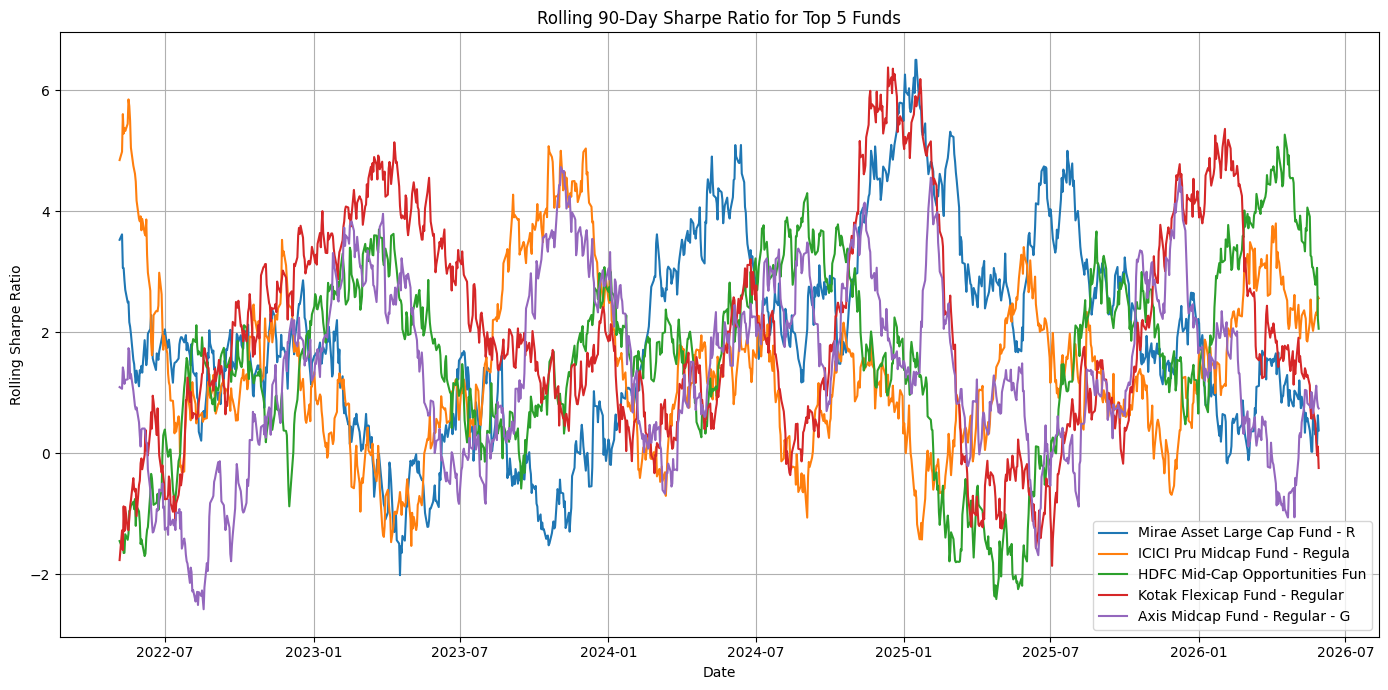

In [13]:
top5_codes = scorecard.sort_values("fund_score", ascending=False)["amfi_code"].head(5).tolist()

plt.figure(figsize=(14, 7))

for code in top5_codes:
    temp = nav[nav["amfi_code"] == code].sort_values("date").copy()
    temp["rolling_sharpe"] = (
        temp["daily_return"].rolling(90).mean() /
        temp["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    name = scorecard.loc[scorecard["amfi_code"] == code, "scheme_name"].iloc[0]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=name[:30])

plt.title("Rolling 90-Day Sharpe Ratio for Top 5 Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../reports/rolling_sharpe_chart.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
first_txn = transactions.groupby("investor_id")["transaction_date"].min().reset_index()
first_txn["cohort_year"] = first_txn["transaction_date"].dt.year

txn_cohort = transactions.merge(
    first_txn[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

cohort_analysis = txn_cohort.groupby("cohort_year").agg(
    investors=("investor_id", "nunique"),
    total_invested=("amount_inr", "sum"),
    avg_transaction_amount=("amount_inr", "mean"),
    avg_sip_amount=("amount_inr", lambda x: x[txn_cohort.loc[x.index, "transaction_type"] == "SIP"].mean())
).reset_index()

preferred_fund = (
    txn_cohort.groupby(["cohort_year", "amfi_code"])["amount_inr"]
    .sum()
    .reset_index()
    .sort_values(["cohort_year", "amount_inr"], ascending=[True, False])
    .groupby("cohort_year")
    .head(1)
)

preferred_fund = preferred_fund.merge(
    scorecard[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

cohort_analysis = cohort_analysis.merge(
    preferred_fund[["cohort_year", "scheme_name", "fund_house"]],
    on="cohort_year",
    how="left"
)

cohort_analysis.to_csv("../data/processed/cohort_analysis.csv", index=False)

cohort_analysis

,cohort_year,investors,total_invested,avg_transaction_amount,avg_sip_amount,scheme_name,fund_house
0,2024,4803,3491125187,107422.541832,10996.885825,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund
1,2025,197,30455243,109158.577061,13505.209581,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund


In [15]:
sip_data = transactions[transactions["transaction_type"] == "SIP"].copy()
sip_data = sip_data.sort_values(["investor_id", "transaction_date"])

sip_counts = sip_data.groupby("investor_id").size().reset_index(name="sip_count")
eligible_investors = sip_counts[sip_counts["sip_count"] >= 6]["investor_id"]

sip_eligible = sip_data[sip_data["investor_id"].isin(eligible_investors)].copy()
sip_eligible["gap_days"] = sip_eligible.groupby("investor_id")["transaction_date"].diff().dt.days

sip_continuity = sip_eligible.groupby("investor_id").agg(
    sip_count=("transaction_id", "count"),
    avg_gap_days=("gap_days", "mean"),
    total_sip_amount=("amount_inr", "sum")
).reset_index()

sip_continuity["risk_status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

sip_continuity.to_csv("../data/processed/sip_continuity.csv", index=False)

sip_continuity.head()

,investor_id,sip_count,avg_gap_days,total_sip_amount,risk_status
0,INV000004,6,85.400000,48256,At-Risk
1,INV000008,6,70.400000,72853,At-Risk
2,INV000010,6,64.800000,32183,At-Risk
3,INV000011,7,40.166667,93920,At-Risk
4,INV000012,8,57.000000,40139,At-Risk


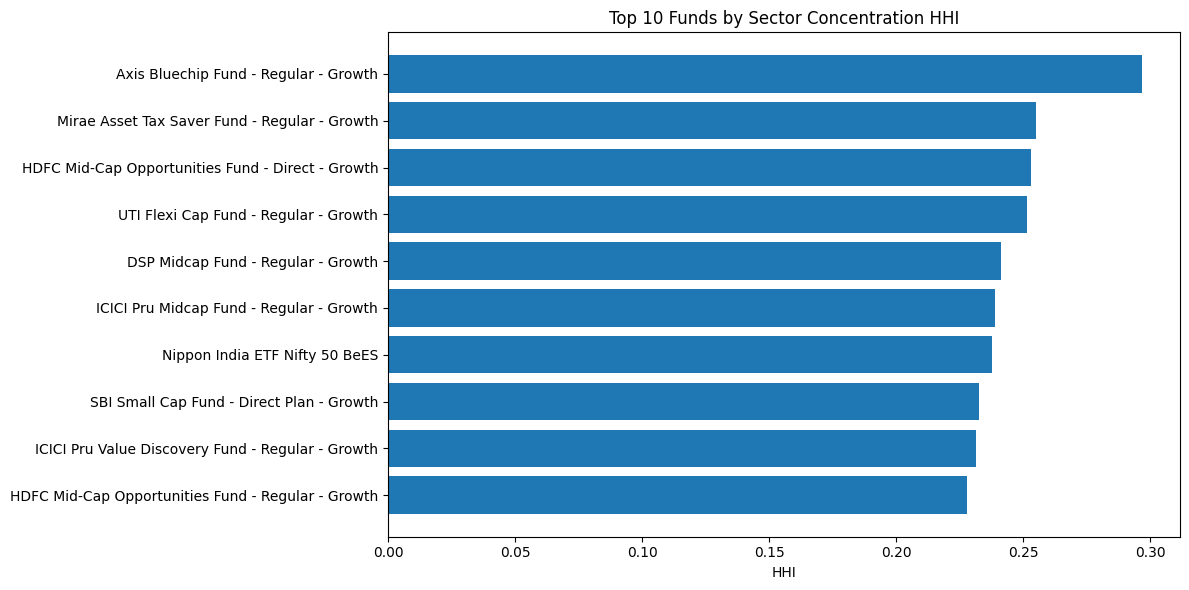

,amfi_code,sector_hhi,sector_count,scheme_name,fund_house,category,sub_category,concentration_risk
0,100016,0.180588,8,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Large Cap,Moderate
1,100033,0.227647,7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Mid Cap,Moderate
2,101206,0.180042,7,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,Moderate
3,101207,0.222727,6,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Small Cap,Moderate
4,102885,0.180712,8,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity,Index,Moderate


In [16]:
sector_weights = portfolio.groupby(["amfi_code", "sector"])["weight_pct"].sum().reset_index()

sector_weights["weight_decimal"] = sector_weights["weight_pct"] / 100

sector_hhi = sector_weights.groupby("amfi_code").agg(
    sector_hhi=("weight_decimal", lambda x: np.sum(x ** 2)),
    sector_count=("sector", "nunique")
).reset_index()

sector_hhi = sector_hhi.merge(
    scorecard[["amfi_code", "scheme_name", "fund_house", "category", "sub_category"]],
    on="amfi_code",
    how="left"
)

sector_hhi["concentration_risk"] = np.where(
    sector_hhi["sector_hhi"] > 0.25,
    "High",
    np.where(sector_hhi["sector_hhi"] > 0.15, "Moderate", "Low")
)

sector_hhi.to_csv("../data/processed/sector_hhi.csv", index=False)

plt.figure(figsize=(12, 6))
top_hhi = sector_hhi.sort_values("sector_hhi", ascending=False).head(10)
plt.barh(top_hhi["scheme_name"], top_hhi["sector_hhi"])
plt.title("Top 10 Funds by Sector Concentration HHI")
plt.xlabel("HHI")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/sector_hhi_chart.png", dpi=300, bbox_inches="tight")
plt.show()

sector_hhi.head()

In [17]:
recommender_code = '''
import pandas as pd
from pathlib import Path

DATA = Path(__file__).resolve().parents[1] / "data" / "processed"

scorecard = pd.read_csv(DATA / "fund_scorecard.csv")

def recommend_funds(risk_appetite: str, top_n: int = 3):
    risk_appetite = risk_appetite.lower().strip()

    if risk_appetite == "low":
        filtered = scorecard[scorecard["category"].str.contains("Debt", case=False, na=False)]
    elif risk_appetite == "moderate":
        filtered = scorecard[
            scorecard["sub_category"].str.contains("Hybrid|Large", case=False, na=False)
        ]
    else:
        filtered = scorecard[scorecard["category"].str.contains("Equity", case=False, na=False)]

    if filtered.empty:
        filtered = scorecard.copy()

    result = filtered.sort_values("sharpe_ratio", ascending=False).head(top_n)

    return result[[
        "scheme_name",
        "fund_house",
        "category",
        "sub_category",
        "sharpe_ratio",
        "cagr_3yr_pct",
        "fund_score"
    ]]

if __name__ == "__main__":
    for risk in ["Low", "Moderate", "High"]:
        print("\\nRisk Appetite:", risk)
        print(recommend_funds(risk))
'''

with open("../scripts/recommender.py", "w", encoding="utf-8") as f:
    f.write(recommender_code)

print("recommender.py created")

recommender.py created


# Advanced Analytics Summary

1. Historical VaR and CVaR identified the funds with the highest downside risk based on daily return distributions.

2. Rolling 90-day Sharpe analysis shows how risk-adjusted performance changed over time for the top-ranked funds.

3. Investor cohort analysis shows differences in investment behaviour between investors who entered in different years.

4. SIP continuity analysis flags investors with average SIP gaps greater than 35 days as at-risk.

5. Sector HHI analysis identifies funds with concentrated portfolio exposure, helping evaluate diversification risk.